In [1]:
model_slug = "Llama-3.1-70B-Instruct"  # best = 0.98
model_slug = "gemma-2-9b-it"  # best medium = 0.97
model_slug = "Phi-3-mini-128k-instruct"  # best small = 0.97
model_slug = "OLMo-2-1124-7B-Instruct"  # worst above 0.96
model_slug = "Llama-3.1-8B-Instruct"  # worst above 0.95
model_slug = "Olmo-3-7B-Instruct"  # worst above 0.9
model_slug = "gemma-2-2b-it"  # worst above 0.8
model_slug = "Llama-3.2-1B-Instruct"  # worst = 0.61

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load .pt file
data = torch.load(f"results/elicit-beliefs-{model_slug}.pt", weights_only=False)
logits = data["logits"]
top_other_logit = data["top_other_logit"]
top_other_id = data["top_other_id"]
top_other_token = data["top_other_token"]

In [3]:
from supporting_code import WORDS, YES, NO, TRUE, FALSE, PROMPT_TEMPLATES, logits_to_affirm_logit

In [4]:
def present_results(p_affirm_logit):
    import matplotlib.pyplot as plt
    from scipy.special import expit
    import numpy as np

    p_affirm_logit = np.asarray(p_affirm_logit)
    mean_p_affirm = expit(p_affirm_logit).mean(axis=1)
    certainty = np.vstack((mean_p_affirm, 1 - mean_p_affirm)).max(axis=0)
    stdev_p_affirm = p_affirm_logit.std(axis=1)
    
    print('mean certainty:', np.mean(certainty))
    stability = -stdev_p_affirm
    print('mean stability:', np.mean(np.array(stability)))
    
    plt.figure()
    plt.title("Density of certainty of yes/no distributions")
    plt.hist(certainty, bins=np.linspace(0.5, 1, 51), density=True, edgecolor="white")
    plt.xlabel("certainty in [0.5, 1]")
    plt.ylabel("density")
    
    plt.figure()
    plt.title("Belief stability of yes probabilities")
    plt.hist(stability, bins=50, density=True, edgecolor="white")
    plt.xlabel("belief stability in [0, 1]")
    plt.ylabel("density")
    
    plt.show()

In [5]:
p_affirm_logit = logits_to_affirm_logit(logits)

mean certainty: 0.61329526
mean stability: -1.7119538


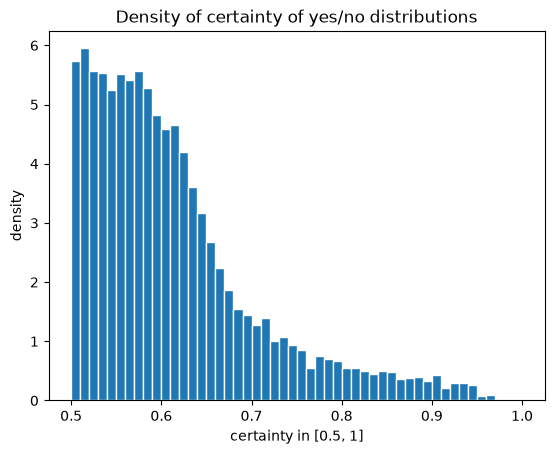

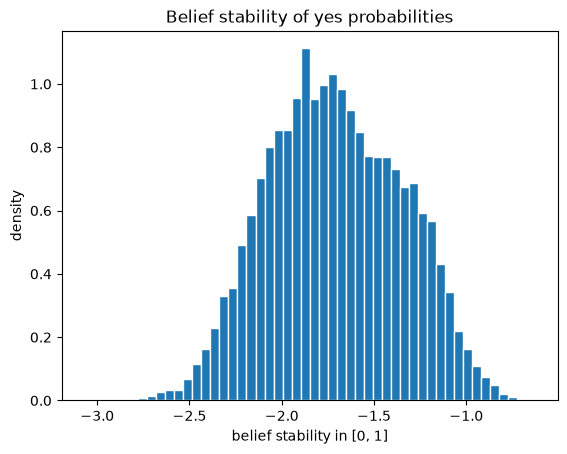

In [6]:
present_results(p_affirm_logit)

mean certainty: 0.6606664
mean stability: -0.9580659


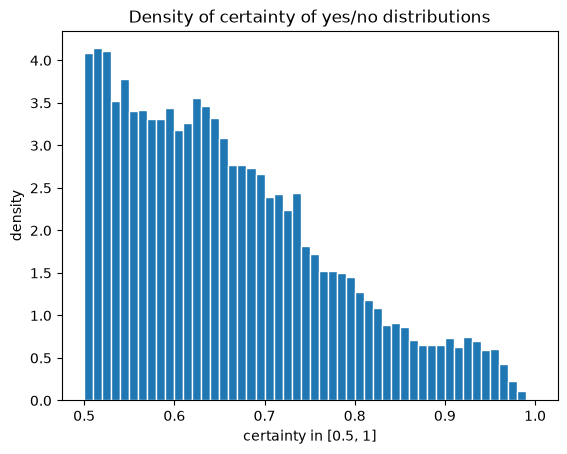

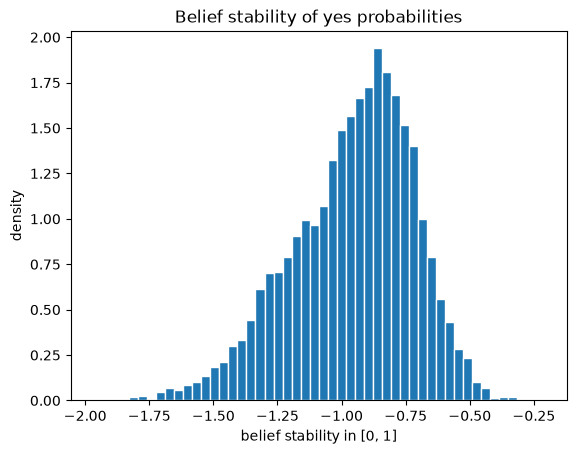

In [7]:
present_results(p_affirm_logit[:, [0, 1, 2, 3]])

mean certainty: 0.6301533
mean stability: -2.024978


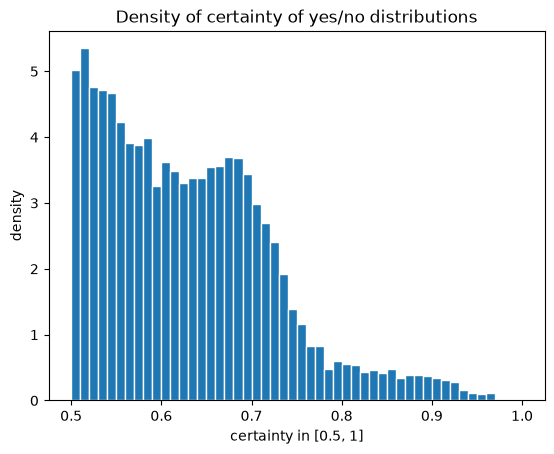

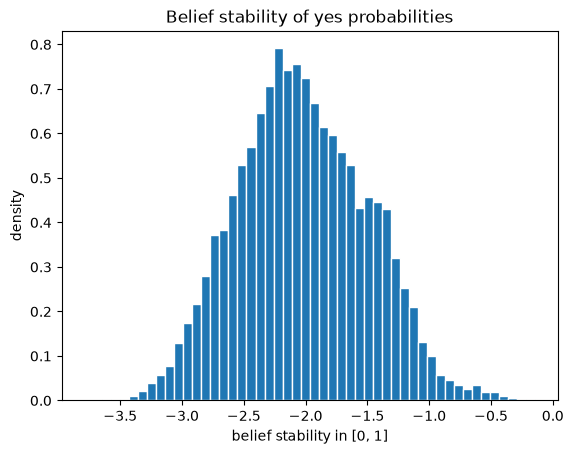

In [8]:
present_results(p_affirm_logit[:, [4, 5, 6, 7]])

mean certainty: 0.7681675
mean stability: -1.2399888


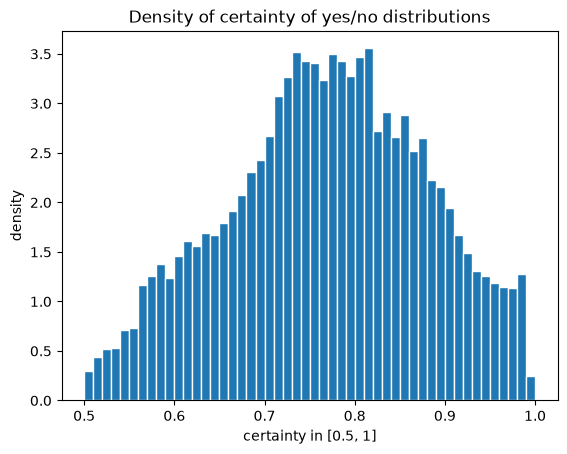

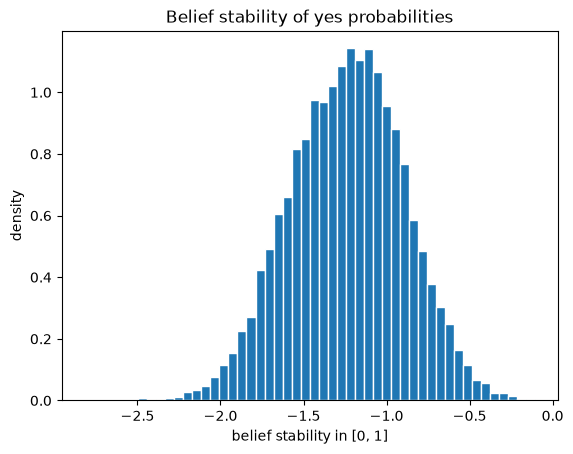

In [9]:
present_results(p_affirm_logit[:, [0, 1, 4, 5]])

mean certainty: 0.68622565
mean stability: -0.9595309


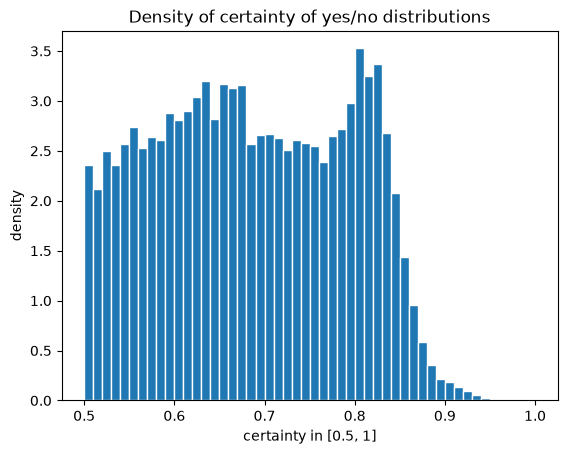

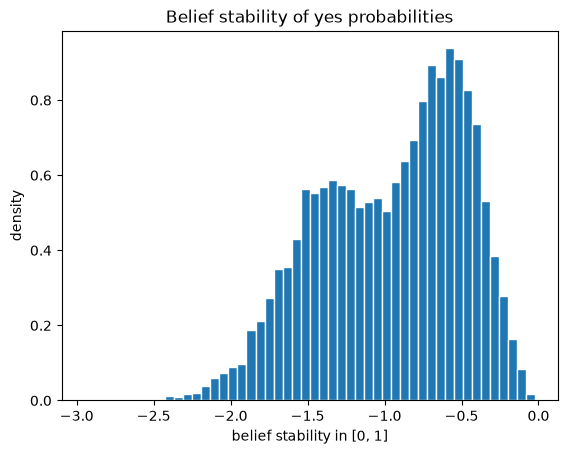

In [10]:
present_results(p_affirm_logit[:, [2, 3, 6, 7]])

In [11]:
c = np.corrcoef(np.transpose(p_affirm_logit))
for row in c:
    print('[ ' + ', '.join(f'{x:4.2f}' for x in row) + ' ]')
print()
print(np.linalg.eig(c)[0][:2] / 8)

[ 1.00, 0.88, 0.95, 0.86, 0.45, 0.39, 0.67, 0.44 ]
[ 0.88, 1.00, 0.90, 0.91, 0.41, 0.27, 0.54, 0.34 ]
[ 0.95, 0.90, 1.00, 0.90, 0.38, 0.30, 0.63, 0.40 ]
[ 0.86, 0.91, 0.90, 1.00, 0.43, 0.39, 0.64, 0.45 ]
[ 0.45, 0.41, 0.38, 0.43, 1.00, 0.67, 0.53, 0.40 ]
[ 0.39, 0.27, 0.30, 0.39, 0.67, 1.00, 0.69, 0.69 ]
[ 0.67, 0.54, 0.63, 0.64, 0.53, 0.69, 1.00, 0.85 ]
[ 0.44, 0.34, 0.40, 0.45, 0.40, 0.69, 0.85, 1.00 ]

[0.64528965 0.19336916]


In [12]:
from scipy.stats import spearmanr
c = spearmanr(p_affirm_logit).statistic
for row in c:
    print('[ ' + ', '.join(f'{x:4.2f}' for x in row) + ' ]')
print()
print(np.linalg.eig(c)[0][:2] / 8)

[ 1.00, 0.83, 0.94, 0.82, 0.39, 0.32, 0.61, 0.41 ]
[ 0.83, 1.00, 0.85, 0.87, 0.34, 0.17, 0.46, 0.30 ]
[ 0.94, 0.85, 1.00, 0.86, 0.31, 0.22, 0.57, 0.37 ]
[ 0.82, 0.87, 0.86, 1.00, 0.38, 0.34, 0.60, 0.45 ]
[ 0.39, 0.34, 0.31, 0.38, 1.00, 0.63, 0.49, 0.37 ]
[ 0.32, 0.17, 0.22, 0.34, 0.63, 1.00, 0.67, 0.69 ]
[ 0.61, 0.46, 0.57, 0.60, 0.49, 0.67, 1.00, 0.85 ]
[ 0.41, 0.30, 0.37, 0.45, 0.37, 0.69, 0.85, 1.00 ]

[0.6071484  0.21077711]


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# The 8 prompt templates, abbreviated for axis labels.
# Adjust these to match your actual template order.
TEMPLATE_LABELS = [
    "Long Yes/No",
    "Long No/Yes",
    "Long True/False",
    "Long False/True",
    "Bare Yes/No",
    "Bare No/Yes",
    "Bare True/False",
    "Bare False/True",
]


def plot_correlation_heatmap(
    corr,
    labels=TEMPLATE_LABELS,
    title=None,
    vmin=0.1,
    vmax=1.0,
    annotate=True,
    cmap="cividis",
    ax=None,
):
    """Plot an 8x8 (or NxN) template-correlation matrix as a colorblind-friendly heatmap.

    Parameters
    ----------
    corr : (N, N) array_like
        Symmetric correlation matrix. Diagonal expected to be ~1.
    labels : list of str
        Tick labels for both axes (length N).
    title : str or None
        Plot title (e.g. the model name).
    vmin, vmax : float
        Colour scale limits. Defaults to [0.4, 1.0] so the interesting
        variation in the 0.4-1.0 range is visible rather than crushed.
        Set vmin lower if a model has correlations below 0.4.
    annotate : bool
        Write the numeric value in each cell.
    cmap : str
        A perceptually-uniform, colourblind-safe colormap. 'cividis' is
        optimised for deuteranopia/protanopia and prints fine in greyscale.
        'viridis' is a good alternative.
    ax : matplotlib Axes or None
        Draw into an existing axes (useful for side-by-side comparisons).
    """
    corr = np.asarray(corr, dtype=float)
    n = corr.shape[0]
    if labels is None:
        labels = [str(i + 1) for i in range(n)]

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7.2, 6.0))
    else:
        fig = ax.figure

    norm = Normalize(vmin=vmin, vmax=vmax)
    im = ax.imshow(corr, cmap=cmap, norm=norm, aspect="equal")

    # Ticks and labels.
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(labels)

    # Minor ticks for clean gridlines between cells.
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(which="major", length=0)

    # Annotate cells. Pick text colour by luminance so it stays readable
    # on both ends of the colormap (don't rely on colour alone).
    if annotate:
        rgba = im.cmap(im.norm(corr))
        # Relative luminance of the cell colour.
        lum = 0.2126 * rgba[..., 0] + 0.7152 * rgba[..., 1] + 0.0722 * rgba[..., 2]
        for i in range(n):
            for j in range(n):
                ax.text(
                    j, i, f"{corr[i, j]:.2f}",
                    ha="center", va="center",
                    color="black" if lum[i, j] > 0.5 else "white",
                    fontsize=9,
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman correlation", rotation=270, labelpad=15)

    if title:
        ax.set_title(title)

    if created_fig:
        fig.tight_layout()

    return fig, ax

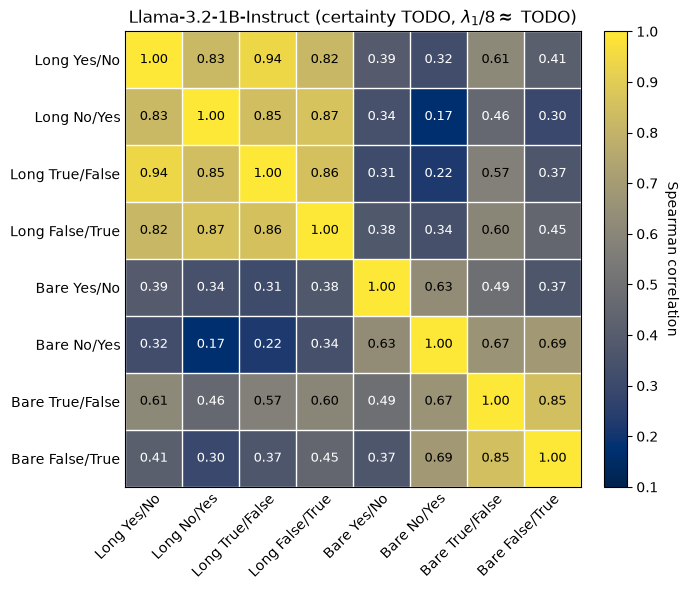

In [14]:
plot_correlation_heatmap(c, title=f"{model_slug} (certainty TODO, $\\lambda_1/8 \\approx $ TODO)");